# NTAS Seminarski rad 2: Mreža cestovnih pravaca između gradova

Zadatak:
- proširenje originalne mreže s 15 novih pravaca i najmanje 5 novih gradova,
- proračun trajanja vožnje za svaki cestovni pravac,
- predstavljanje mreže kao neusmjerenog grafa s dvije vrste težinskih obilježja (udaljenost i vrijeme),
- prikaz susjedstva i matrica susjedstva za obje vrste težina,
- vizualizaciju grafa,
- najkraće puteve za četiri primjera,
- analizu netežinskog grafa: dijametar, gustoću, stupnjeve i četiri mjere centralnosti.

In [24]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

pd.options.display.max_columns = 10
pd.options.display.width = 100

SOURCE_FILE = 'MREZA_CESTOVNIH_PRAVACA.xlsx'
EXTENDED_FILE = 'MREZA_CESTOVNIH_PRAVACA_PROSIRENA.xlsx'

df_originalni_pravci = pd.read_excel(SOURCE_FILE)
df_originalni_pravci['POLAZIŠTE'] = df_originalni_pravci['POLAZIŠTE'].astype(str).str.strip()
df_originalni_pravci['ODREDIŠTE'] = df_originalni_pravci['ODREDIŠTE'].astype(str).str.strip()
df_originalni_pravci = df_originalni_pravci.sort_values(['POLAZIŠTE', 'ODREDIŠTE']).reset_index(drop=True)

print('Originalni broj redaka:', len(df_originalni_pravci))
print('Originalni broj gradova:', len(sorted(set(df_originalni_pravci['POLAZIŠTE']).union(df_originalni_pravci['ODREDIŠTE']))))
print('Originalni gradovi:', sorted(set(df_originalni_pravci['POLAZIŠTE']).union(df_originalni_pravci['ODREDIŠTE'])))
df_originalni_pravci.head(10)

Originalni broj redaka: 31
Originalni broj gradova: 13
Originalni gradovi: ['BJELOVAR', 'DARUVAR', 'GAREŠNICA', 'IVANIĆ GRAD', 'KUTINA', 'NAŠICE', 'NOVSKA', 'PAKRAC', 'POŽEGA', 'VIROVITICA', 'ZAGREB', 'ČAZMA', 'ĐAKOVO']


,POLAZIŠTE,ODREDIŠTE,OZNAKA CESTE,UDALJENOST km,PROSJEČNA BRZ km/h,TRAJANJE [min]
0,BJELOVAR,VIROVITICA,D43 i D2,67.2,63.000000,NaN
1,DARUVAR,NAŠICE,D2,86.1,47.394495,NaN
2,DARUVAR,PAKRAC,NaN,20.9,54.521739,NaN
3,DARUVAR,POŽEGA,E661 i D38,68.0,61.818182,NaN
4,DARUVAR,VIROVITICA,D34,52.1,60.115385,NaN
5,GAREŠNICA,BJELOVAR,D43,44.5,60.681818,NaN
6,GAREŠNICA,DARUVAR,D26,29.5,63.214286,NaN
7,GAREŠNICA,PAKRAC,D26,33.9,58.114286,NaN
8,GAREŠNICA,VIROVITICA,NaN,50.7,62.081633,NaN
9,IVANIĆ GRAD,KUTINA,NaN,44.6,52.470588,NaN


In [25]:
new_edges = [
    ('ZAGREB', 'VARAŽDIN', 'A2/D2', 83.0, 90.0),
    ('VARAŽDIN', 'KOPRIVNICA', 'D2/D41', 63.0, 80.0),
    ('KOPRIVNICA', 'ČAKOVEC', 'D209', 35.0, 80.0),
    ('ZAGREB', 'RIJEKA', 'A6', 165.0, 95.0),
    ('RIJEKA', 'OPATIJA', 'D8', 13.0, 50.0),
    ('OPATIJA', 'PULA', 'A8/D66', 100.0, 80.0),
    ('PULA', 'ZADAR', 'A9/D8', 243.0, 95.0),
    ('ZADAR', 'SPLIT', 'A1', 158.0, 95.0),
    ('SPLIT', 'ŠIBENIK', 'D8', 88.0, 90.0),
    ('ŠIBENIK', 'ZADAR', 'D8', 88.0, 90.0),
    ('VARAŽDIN', 'OSIJEK', 'A4/D2', 185.0, 85.0),
    ('OSIJEK', 'ĐAKOVO', 'D7', 37.0, 70.0),
    ('PULA', 'ZAGREB', 'A1/A9', 263.0, 100.0),
    ('OSIJEK', 'NAŠICE', 'D2/D7', 45.0, 70.0),
    ('KOPRIVNICA', 'NAŠICE', 'D2', 149.0, 80.0),
]

df_novi_pravci = pd.DataFrame(new_edges, columns=['POLAZIŠTE', 'ODREDIŠTE', 'OZNAKA CESTE', 'UDALJENOST km', 'PROSJEČNA BRZ km/h'])
df_novi_pravci['POLAZIŠTE'] = df_novi_pravci['POLAZIŠTE'].astype(str).str.strip()
df_novi_pravci['ODREDIŠTE'] = df_novi_pravci['ODREDIŠTE'].astype(str).str.strip()

df_prosireni_pravci = pd.concat([df_originalni_pravci, df_novi_pravci], ignore_index=True)
df_prosireni_pravci['TRAJANJE [min]'] = (df_prosireni_pravci['UDALJENOST km'] / df_prosireni_pravci['PROSJEČNA BRZ km/h']) * 60
df_prosireni_pravci = df_prosireni_pravci.sort_values(['POLAZIŠTE', 'ODREDIŠTE']).reset_index(drop=True)
df_prosireni_pravci['TRAJANJE [min]'] = df_prosireni_pravci['TRAJANJE [min]'].round(1)

originalni_gradovi = set(df_originalni_pravci['POLAZIŠTE']).union(df_originalni_pravci['ODREDIŠTE'])
svi_gradovi = set(df_prosireni_pravci['POLAZIŠTE']).union(df_prosireni_pravci['ODREDIŠTE'])
novi_gradovi = sorted(svi_gradovi - originalni_gradovi)

print('Ukupni broj redaka u proširenoj mreži:', len(df_prosireni_pravci))
print('Ukupni broj različitih gradova:', len(svi_gradovi))
print('Novi gradovi u mreži:', novi_gradovi)
df_prosireni_pravci.tail(15)

df_prosireni_pravci.to_excel(EXTENDED_FILE, index=False)
print(f'Proširena Excel datoteka spremljena kao: {EXTENDED_FILE}')

Ukupni broj redaka u proširenoj mreži: 46
Ukupni broj različitih gradova: 23
Novi gradovi u mreži: ['KOPRIVNICA', 'OPATIJA', 'OSIJEK', 'PULA', 'RIJEKA', 'SPLIT', 'VARAŽDIN', 'ZADAR', 'ČAKOVEC', 'ŠIBENIK']
Proširena Excel datoteka spremljena kao: MREZA_CESTOVNIH_PRAVACA_PROSIRENA.xlsx


In [26]:
def build_graph(df, weight_col):
    G = nx.Graph()
    for _, row in df.iterrows():
        u = row['POLAZIŠTE']
        v = row['ODREDIŠTE']
        G.add_edge(u, v, distance=float(row['UDALJENOST km']), time=float(row['TRAJANJE [min]']), road=str(row['OZNAKA CESTE']))
    return G

graf_udaljenost = build_graph(df_prosireni_pravci, 'UDALJENOST km')
graf_trajanje = build_graph(df_prosireni_pravci, 'TRAJANJE [min]')
graf_netezinski = nx.Graph()
graf_netezinski.add_nodes_from(graf_udaljenost.nodes())
graf_netezinski.add_edges_from(graf_udaljenost.edges())

print('Broj čvorova grafa:', graf_udaljenost.number_of_nodes())
print('Broj bridova grafa:', graf_udaljenost.number_of_edges())
print('Je li graf povezan (neusmjereno):', nx.is_connected(graf_udaljenost))

label_map = {
    'ZAGREB': 'ZG', 'KUTINA': 'KT', 'BJELOVAR': 'BJ', 'DARUVAR': 'DR',
    'GAREŠNICA': 'GR', 'IVANIĆ GRAD': 'IG', 'NOVSKA': 'NV', 'POŽEGA': 'PŽ',
    'VIROVITICA': 'VT', 'ČAZMA': 'ČZ', 'ĐAKOVO': 'ĐK', 'NAŠICE': 'NS',
    'VARAŽDIN': 'VR', 'KOPRIVNICA': 'KP', 'ČAKOVEC': 'ČC', 'RIJEKA': 'RK',
    'OPATIJA': 'OP', 'PULA': 'PL', 'ZADAR': 'ZD', 'SPLIT': 'SP', 'ŠIBENIK': 'ŠB',
    'OSIJEK': 'OS'
}
abbr_labels = {node: label_map.get(node, node[:2]) for node in graf_udaljenost.nodes()}
pos = nx.spring_layout(graf_udaljenost, seed=42, k=0.5)

Broj čvorova grafa: 23
Broj bridova grafa: 46
Je li graf povezan (neusmjereno): True


## 1. Lista susjedstva i matrica susjedstva

Prikazujemo susjedstvo i matricu susjedstva za oba slučaja otežanosti (udaljenost i vrijeme). U grafu se radi o neusmjerenom grafu.

In [27]:
def adjacency_list(G, weight_key):
    result = {}
    for node in sorted(G.nodes()):
        neighbors = []
        for nbr, data in sorted(G[node].items()):
            neighbors.append((nbr, round(data[weight_key], 1)))
        result[node] = neighbors
    return result

susjedstvo_udaljenost = adjacency_list(graf_udaljenost, 'distance')
susjedstvo_trajanje = adjacency_list(graf_trajanje, 'time')

print('Primjer susjedstva za udaljenost (prvih 8 čvorova):')
for node in list(susjedstvo_udaljenost)[:8]:
    print(f'{abbr_labels[node]:>3} ({node}):', susjedstvo_udaljenost[node])

print('\nPrimjer susjedstva za trajanje (prvih 8 čvorova):')
for node in list(susjedstvo_trajanje)[:8]:
    print(f'{abbr_labels[node]:>3} ({node}):', susjedstvo_trajanje[node])

matrica_susjedstva_udaljenost = nx.to_pandas_adjacency(graf_udaljenost, weight='distance').round(1)
matrica_susjedstva_trajanje = nx.to_pandas_adjacency(graf_trajanje, weight='time').round(1)

print('Matrica susjedstva za udaljenost:')
matrica_susjedstva_udaljenost

Primjer susjedstva za udaljenost (prvih 8 čvorova):
 BJ (BJELOVAR): [('GAREŠNICA', 44.5), ('VIROVITICA', 67.2), ('ZAGREB', 83.9), ('ČAZMA', 30.8)]
 DR (DARUVAR): [('GAREŠNICA', 29.5), ('NAŠICE', 86.1), ('PAKRAC', 20.9), ('POŽEGA', 68.0), ('VIROVITICA', 52.1)]
 GR (GAREŠNICA): [('BJELOVAR', 44.5), ('DARUVAR', 29.5), ('KUTINA', 19.4), ('PAKRAC', 33.9), ('VIROVITICA', 50.7)]
 IG (IVANIĆ GRAD): [('KUTINA', 44.6), ('ZAGREB', 59.2), ('ČAZMA', 19.1)]
 KP (KOPRIVNICA): [('NAŠICE', 149.0), ('VARAŽDIN', 63.0), ('ČAKOVEC', 35.0)]
 KT (KUTINA): [('GAREŠNICA', 19.4), ('IVANIĆ GRAD', 44.6), ('NOVSKA', 25.6), ('VIROVITICA', 70.0), ('ZAGREB', 82.5)]
 NS (NAŠICE): [('DARUVAR', 86.1), ('KOPRIVNICA', 149.0), ('OSIJEK', 45.0), ('PAKRAC', 95.3), ('POŽEGA', 47.2), ('VIROVITICA', 77.2), ('ĐAKOVO', 34.8)]
 NV (NOVSKA): [('KUTINA', 25.6), ('PAKRAC', 26.1), ('POŽEGA', 66.6)]

Primjer susjedstva za trajanje (prvih 8 čvorova):
 BJ (BJELOVAR): [('GAREŠNICA', 44.0), ('VIROVITICA', 64.0), ('ZAGREB', 79.0), ('ČAZMA',

,BJELOVAR,VIROVITICA,DARUVAR,NAŠICE,PAKRAC,...,ZAGREB,RIJEKA,SPLIT,ŠIBENIK,VARAŽDIN
BJELOVAR,0.0,67.2,0.0,0.0,0.0,...,83.9,0.0,0.0,0.0,0.0
VIROVITICA,67.2,0.0,52.1,77.2,0.0,...,141.0,0.0,0.0,0.0,0.0
DARUVAR,0.0,52.1,0.0,86.1,20.9,...,0.0,0.0,0.0,0.0,0.0
NAŠICE,0.0,77.2,86.1,0.0,95.3,...,0.0,0.0,0.0,0.0,0.0
PAKRAC,0.0,0.0,20.9,95.3,0.0,...,0.0,0.0,0.0,0.0,0.0
POŽEGA,0.0,90.7,68.0,47.2,49.4,...,174.0,0.0,0.0,0.0,0.0
GAREŠNICA,44.5,50.7,29.5,0.0,33.9,...,0.0,0.0,0.0,0.0,0.0
IVANIĆ GRAD,0.0,0.0,0.0,0.0,0.0,...,59.2,0.0,0.0,0.0,0.0
KUTINA,0.0,70.0,0.0,0.0,0.0,...,82.5,0.0,0.0,0.0,0.0
ČAZMA,30.8,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0


In [28]:
print('Matrica susjedstva za trajanje:')
matrica_susjedstva_trajanje

Matrica susjedstva za trajanje:


,BJELOVAR,VIROVITICA,DARUVAR,NAŠICE,PAKRAC,...,ZAGREB,RIJEKA,SPLIT,ŠIBENIK,VARAŽDIN
BJELOVAR,0.0,64.0,0.0,0.0,0.0,...,79.0,0.0,0.0,0.0,0.0
VIROVITICA,64.0,0.0,52.0,73.0,0.0,...,148.0,0.0,0.0,0.0,0.0
DARUVAR,0.0,52.0,0.0,109.0,23.0,...,0.0,0.0,0.0,0.0,0.0
NAŠICE,0.0,73.0,109.0,0.0,92.0,...,0.0,0.0,0.0,0.0,0.0
PAKRAC,0.0,0.0,23.0,92.0,0.0,...,0.0,0.0,0.0,0.0,0.0
POŽEGA,0.0,95.0,66.0,51.0,45.0,...,115.0,0.0,0.0,0.0,0.0
GAREŠNICA,44.0,49.0,28.0,0.0,35.0,...,0.0,0.0,0.0,0.0,0.0
IVANIĆ GRAD,0.0,0.0,0.0,0.0,0.0,...,48.0,0.0,0.0,0.0,0.0
KUTINA,0.0,67.0,0.0,0.0,0.0,...,58.0,0.0,0.0,0.0,0.0
ČAZMA,32.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0


## 2. Vizualizacija grafa

Prikazujemo grafove s etiketama čvorova i vrijednostima težina za udaljenost i vrijeme.

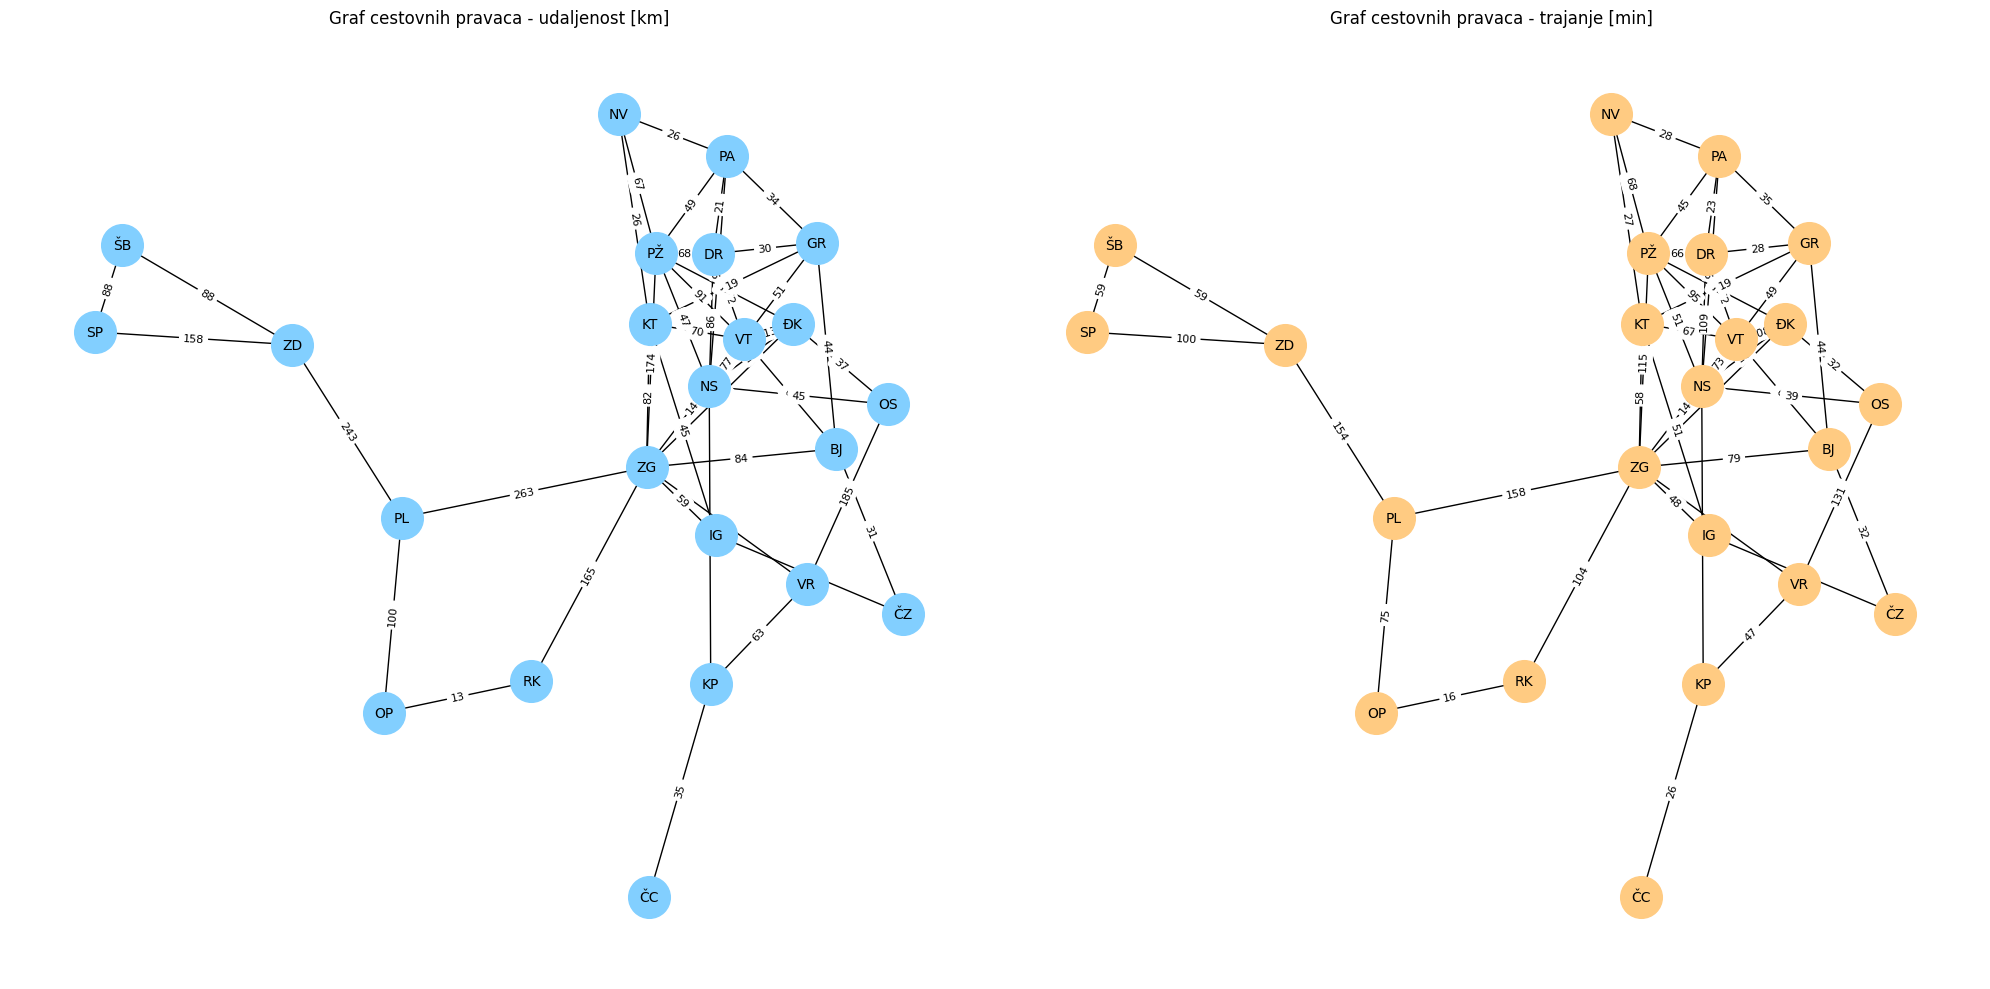

Grafovi spremljeni kao graf_udaljenost_i_trajanje.png


In [29]:
oznake_bridova_udaljenost = {(u, v): f"{d['distance']:.0f}" for u, v, d in graf_udaljenost.edges(data=True)}
oznake_bridova_trajanje = {(u, v): f"{d['time']:.0f}" for u, v, d in graf_trajanje.edges(data=True)}

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

plt.sca(axes[0])
nx.draw(graf_udaljenost, pos=pos, labels=abbr_labels, node_size=900, node_color='#82cfff', font_size=10)
nx.draw_networkx_edge_labels(graf_udaljenost, pos=pos, edge_labels=oznake_bridova_udaljenost, font_color='black', font_size=8)
plt.title('Graf cestovnih pravaca - udaljenost [km]')
plt.axis('off')

plt.sca(axes[1])
nx.draw(graf_trajanje, pos=pos, labels=abbr_labels, node_size=900, node_color='#ffcb82', font_size=10)
nx.draw_networkx_edge_labels(graf_trajanje, pos=pos, edge_labels=oznake_bridova_trajanje, font_color='black', font_size=8)
plt.title('Graf cestovnih pravaca - trajanje [min]')
plt.axis('off')

plt.tight_layout()
plt.show()

fig.savefig('graf_udaljenost_i_trajanje.png', dpi=150)
print('Grafovi spremljeni kao graf_udaljenost_i_trajanje.png')

## 3. Najkraći putevi za primjere

Izračunavamo najkraće puteve za četiri primjera, i za težinu udaljenost i za težinu trajanje.

In [30]:
examples = [
    ('ZAGREB', 'SPLIT'),
    ('ZAGREB', 'OSIJEK'),
    ('ČAZMA', 'PULA'),
    ('NAŠICE', 'ŠIBENIK'),
]

def path_info(G, source, target, weight):
    path = nx.shortest_path(G, source=source, target=target, weight=weight)
    length = nx.shortest_path_length(G, source=source, target=target, weight=weight)
    return path, length

for source, target in examples:
    print(f'Primjer: {source} → {target}')
    path_po_udaljenosti, udaljenost = path_info(graf_udaljenost, source, target, 'distance')
    path_po_trajanju, trajanje = path_info(graf_trajanje, source, target, 'time')
    print('  Udaljenost [km]:', round(udaljenost, 1), 'km, put:', ' → '.join(path_po_udaljenosti))
    print('  Trajanje [min]:', round(trajanje, 1), 'min, put:', ' → '.join(path_po_trajanju))
    print()

Primjer: ZAGREB → SPLIT
  Udaljenost [km]: 664.0 km, put: ZAGREB → PULA → ZADAR → SPLIT
  Trajanje [min]: 411.1 min, put: ZAGREB → PULA → ZADAR → SPLIT

Primjer: ZAGREB → OSIJEK
  Udaljenost [km]: 262.5 km, put: ZAGREB → KUTINA → GAREŠNICA → DARUVAR → NAŠICE → OSIJEK
  Trajanje [min]: 167.7 min, put: ZAGREB → ĐAKOVO → OSIJEK

Primjer: ČAZMA → PULA
  Udaljenost [km]: 341.3 km, put: ČAZMA → IVANIĆ GRAD → ZAGREB → PULA
  Trajanje [min]: 226.8 min, put: ČAZMA → IVANIĆ GRAD → ZAGREB → PULA

Primjer: NAŠICE → ŠIBENIK
  Udaljenost [km]: 811.5 km, put: NAŠICE → DARUVAR → GAREŠNICA → KUTINA → ZAGREB → PULA → ZADAR → ŠIBENIK
  Trajanje [min]: 536.0 min, put: NAŠICE → POŽEGA → ZAGREB → PULA → ZADAR → ŠIBENIK



## 4. Analiza netežinskog grafa

Određujemo dijametar, gustoću i stupnjeve svih čvorova te četiri važne mjere centralnosti.

In [31]:
print('Je li netežinski graf povezan:', nx.is_connected(graf_netezinski))
print('Dijametar grafa:', nx.diameter(graf_netezinski))
print('Gustoća grafa:', round(nx.density(graf_netezinski), 3))

print('\nStupnjevi čvorova:')
for node, degree in sorted(graf_netezinski.degree(), key=lambda x: (-x[1], x[0])):
    print(f'  {abbr_labels[node]:>3} ({node}): {degree}')

mjere_centralnosti = {
    'stupanj': nx.degree_centrality(graf_netezinski),
    'medupoloznost': nx.betweenness_centrality(graf_netezinski),
    'bliskost': nx.closeness_centrality(graf_netezinski),
    'svojstvena_vrijednost': nx.eigenvector_centrality(graf_netezinski, max_iter=200),
}

df_centralnosti = pd.DataFrame(mjere_centralnosti).rename_axis('Grad').round(4)
df_centralnosti = df_centralnosti.sort_values(by='medupoloznost', ascending=False)
df_centralnosti

Je li netežinski graf povezan: True
Dijametar grafa: 6
Gustoća grafa: 0.182

Stupnjevi čvorova:
   ZG (ZAGREB): 9
   VT (VIROVITICA): 8
   NS (NAŠICE): 7
   PŽ (POŽEGA): 7
   DR (DARUVAR): 5
   GR (GAREŠNICA): 5
   KT (KUTINA): 5
   PA (PAKRAC): 5
   ĐK (ĐAKOVO): 5
   BJ (BJELOVAR): 4
   IG (IVANIĆ GRAD): 3
   KP (KOPRIVNICA): 3
   NV (NOVSKA): 3
   OS (OSIJEK): 3
   PL (PULA): 3
   VR (VARAŽDIN): 3
   ZD (ZADAR): 3
   OP (OPATIJA): 2
   RK (RIJEKA): 2
   SP (SPLIT): 2
   ČZ (ČAZMA): 2
   ŠB (ŠIBENIK): 2
   ČC (ČAKOVEC): 1


,stupanj,medupoloznost,bliskost,svojstvena_vrijednost
Grad,,,,
ZAGREB,0.4091,0.5357,0.5789,0.3323
PULA,0.1364,0.2835,0.4314,0.0668
ZADAR,0.1364,0.1732,0.3235,0.0132
VARAŽDIN,0.1364,0.1089,0.4231,0.0982
NAŠICE,0.3182,0.1082,0.4314,0.3322
VIROVITICA,0.3636,0.1064,0.5116,0.4145
POŽEGA,0.3182,0.1032,0.4889,0.3747
KOPRIVNICA,0.1364,0.0956,0.3667,0.0806
BJELOVAR,0.1818,0.0649,0.4314,0.1904


### Zapažanja

- Graf je povezan nakon dodavanja novih pravaca, što znači da između bilo koja dva grada postoji rješenje.
- Netežinski dijametar odražava maksimalni broj koraka između najudaljenijih gradova u mreži.
- Centralnosti pokazuju koji su čvorovi najvažniji za povezivanje različitih dijelova mreže.
- Udaljenost i trajanje daju različite rute u pojedinim primjerima, jer najkraći put kilometrima nije nužno najbrži.